<a href="https://colab.research.google.com/github/JonasCandid0/TCC-Univesp/blob/main/tcc_analise_espacial_simba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [ ]:
!pip install geopandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, LineString


# Tratemento inicial
---

### Esforços de Monitoramento

In [ ]:
caminho_monitoramento ='/content/drive/MyDrive/fontes de dados SIMBA/Esforcos_de_Monitoramento.csv'

In [ ]:
colunas_esforco = [
    'Estado', 'Cidade', 'Praia', 'Trecho',
    'Tipo', 'Estratégia', 'Tipo de veículo',
    'Data/Hora início', 'Data/Hora término',
    'Latitude ponto inicial', 'Longitude ponto inicial',
    'Latitude ponto final', 'Longitude ponto final',
]

In [ ]:
esforco_monitora_filtrada = pd.read_csv(
    caminho_monitoramento,
    sep=";",
    usecols=colunas_esforco ,
    low_memory=False
)

In [ ]:
esforco_monitora_filtrada.head()

,Estado,Cidade,Praia,Trecho,Tipo,Estratégia,Tipo de veículo,Data/Hora início,Data/Hora término,Latitude ponto inicial,Longitude ponto inicial,Latitude ponto final,Longitude ponto final
0,São Paulo,Ubatuba,Caçandoquinha,Caçandoquinha,Terrestre,Diário,A pé,11/12/2025 09:05,11/12/2025 09:10,-235.650.047,-452.160.215,-235.656.297,-452.147.579
1,São Paulo,Iguape,Iguape - Praia da Juréia,Iguape - Praia da Juréia,Terrestre,Diário,Quadriciclo,11/12/2025 07:12,11/12/2025 07:29,-2.457.369,-4.724.538,-2.462.115,-4.732.833
2,São Paulo,Ubatuba,Itaipu,Itaipu,Terrestre,Diário,A pé,11/12/2025 10:13,11/12/2025 10:17,-233.789.236,-449.542.363,-233.789.307,-449.543.609
3,São Paulo,Ubatuba,Praia do Félix,Praia do Félix,Terrestre,Diário,A pé,11/12/2025 09:30,11/12/2025 10:12,-233.928.409,-44.972.134,-233.787.668,-449.547.581
4,São Paulo,Ubatuba,Vermelha do Norte,Vermelha do Norte,Terrestre,Diário,A pé,11/12/2025 08:18,11/12/2025 08:37,-234.213.601,-450.393.365,-234.133.945,-450.315.544


In [ ]:
esforco_monitora_filtrada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428371 entries, 0 to 428370
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Estado                   428371 non-null  object
 1   Cidade                   428371 non-null  object
 2   Praia                    428371 non-null  object
 3   Trecho                   428371 non-null  object
 4   Tipo                     428371 non-null  object
 5   Estratégia               428371 non-null  object
 6   Tipo de veículo          428331 non-null  object
 7   Data/Hora início         428371 non-null  object
 8   Data/Hora término        428371 non-null  object
 9   Latitude ponto inicial   428371 non-null  object
 10  Longitude ponto inicial  428371 non-null  object
 11  Latitude ponto final     428371 non-null  object
 12  Longitude ponto final    428371 non-null  object
dtypes: object(13)
memory usage: 42.5+ MB


In [ ]:
# Conversão de tipos — Esforços de Monitoramento

# 1. Datas
esforco_monitora_filtrada['Data/Hora início'] = pd.to_datetime(
    esforco_monitora_filtrada['Data/Hora início'], dayfirst=True, errors='coerce'
)
esforco_monitora_filtrada['Data/Hora término'] = pd.to_datetime(
    esforco_monitora_filtrada['Data/Hora término'], dayfirst=True, errors='coerce'
)

In [ ]:
# 2. Variáveis categóricas (baixa cardinalidade — economiza memória RAM)
colunas_cat_esforco = ['Estado', 'Cidade', 'Praia', 'Trecho', 'Tipo', 'Estratégia', 'Tipo de veículo']
for col in colunas_cat_esforco:
    esforco_monitora_filtrada[col] = esforco_monitora_filtrada[col].astype('category')

print(' Esforços — tipos convertidos:')
esforco_monitora_filtrada.dtypes

 Esforços — tipos convertidos:


,0
Estado,category
Cidade,category
Praia,category
Trecho,category
Tipo,category
Estratégia,category
Tipo de veículo,category
Data/Hora início,datetime64[ns]
Data/Hora término,datetime64[ns]
Latitude ponto inicial,object


In [ ]:
esforco_monitora_filtrada.head()

,Estado,Cidade,Praia,Trecho,Tipo,Estratégia,Tipo de veículo,Data/Hora início,Data/Hora término,Latitude ponto inicial,Longitude ponto inicial,Latitude ponto final,Longitude ponto final
0,São Paulo,Ubatuba,Caçandoquinha,Caçandoquinha,Terrestre,Diário,A pé,2025-12-11 09:05:00,2025-12-11 09:10:00,-235.650.047,-452.160.215,-235.656.297,-452.147.579
1,São Paulo,Iguape,Iguape - Praia da Juréia,Iguape - Praia da Juréia,Terrestre,Diário,Quadriciclo,2025-12-11 07:12:00,2025-12-11 07:29:00,-2.457.369,-4.724.538,-2.462.115,-4.732.833
2,São Paulo,Ubatuba,Itaipu,Itaipu,Terrestre,Diário,A pé,2025-12-11 10:13:00,2025-12-11 10:17:00,-233.789.236,-449.542.363,-233.789.307,-449.543.609
3,São Paulo,Ubatuba,Praia do Félix,Praia do Félix,Terrestre,Diário,A pé,2025-12-11 09:30:00,2025-12-11 10:12:00,-233.928.409,-44.972.134,-233.787.668,-449.547.581
4,São Paulo,Ubatuba,Vermelha do Norte,Vermelha do Norte,Terrestre,Diário,A pé,2025-12-11 08:18:00,2025-12-11 08:37:00,-234.213.601,-450.393.365,-234.133.945,-450.315.544


In [ ]:
esforco_monitora_filtrada.head()

,Estado,Cidade,Praia,Trecho,Tipo,Estratégia,Tipo de veículo,Data/Hora início,Data/Hora término,Latitude ponto inicial,Longitude ponto inicial,Latitude ponto final,Longitude ponto final
0,São Paulo,Ubatuba,Caçandoquinha,Caçandoquinha,Terrestre,Diário,A pé,2025-12-11 09:05:00,2025-12-11 09:10:00,-235.650.047,-452.160.215,-235.656.297,-452.147.579
1,São Paulo,Iguape,Iguape - Praia da Juréia,Iguape - Praia da Juréia,Terrestre,Diário,Quadriciclo,2025-12-11 07:12:00,2025-12-11 07:29:00,-2.457.369,-4.724.538,-2.462.115,-4.732.833
2,São Paulo,Ubatuba,Itaipu,Itaipu,Terrestre,Diário,A pé,2025-12-11 10:13:00,2025-12-11 10:17:00,-233.789.236,-449.542.363,-233.789.307,-449.543.609
3,São Paulo,Ubatuba,Praia do Félix,Praia do Félix,Terrestre,Diário,A pé,2025-12-11 09:30:00,2025-12-11 10:12:00,-233.928.409,-44.972.134,-233.787.668,-449.547.581
4,São Paulo,Ubatuba,Vermelha do Norte,Vermelha do Norte,Terrestre,Diário,A pé,2025-12-11 08:18:00,2025-12-11 08:37:00,-234.213.601,-450.393.365,-234.133.945,-450.315.544


### Biometria

In [ ]:
caminho_biometria ='/content/drive/MyDrive/fontes de dados SIMBA/Biometrias_arrumando.csv'

In [ ]:
biometria = pd.read_csv(caminho_biometria, sep=";", encoding='utf-8')

In [ ]:
biometria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31440 entries, 0 to 31439
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Código                       31440 non-null  int64 
 1   Identificador da ocorrência  31440 non-null  object
 2   Identificador do indivíduo   31440 non-null  int64 
 3   Espécies - Classe            31440 non-null  object
 4   Espécies - Ordem             31438 non-null  object
 5   Espécies - Subordem          14754 non-null  object
 6   Espécies - Família           31404 non-null  object
 7   Espécies - Gênero            31322 non-null  object
 8   Espécies - Espécie           30964 non-null  object
 9   Ficha de campo               16847 non-null  object
 10  Instituição executora        31440 non-null  object
 11  Data                         31440 non-null  object
 12  Tipo                         31440 non-null  object
 13  Responsável                  31

In [ ]:
colunas_selecionadas = ["Identificador da ocorrência", "Identificador do indivíduo", "Espécies - Classe",
                         "Espécies - Espécie", "Ficha de campo", "Instituição executora", "Tipo", "Responsável"
]

biometria_filtrada = biometria[colunas_selecionadas]

In [ ]:
biometria_filtrada.head()

,Identificador da ocorrência,Identificador do indivíduo,Espécies - Classe,Espécies - Espécie,Ficha de campo,Instituição executora,Tipo,Responsável
0,T10RE20251211i285083,436146,Reptilia,Chelonia mydas,IA19995,Trecho 10,Quelônio,Bruno Gonçalves Pereira
1,T10MA20251211i000002,446486,Mammalia,Sotalia guianensis,IA19997,Trecho 10,Odontoceti,Guilherme Fluckiger
2,T10RE20251211i404061,432935,Reptilia,Chelonia mydas,IA19996,Trecho 10,Quelônio,André Eduardo Silva Colferai
3,T10MA20251127i404059,432933,Mammalia,Pontoporia blainvillei,IA19901,Trecho 10,Odontoceti,André Eduardo Silva Colferai
4,T10RE20251118i404058,432932,Reptilia,Chelonia mydas,IA19845,Trecho 10,Quelônio,André Eduardo Silva Colferai


In [ ]:
# Conversão de tipos — Biometria

# 1. Desvinculamos a tabela da visualização original
biometria_filtrada = biometria_filtrada.copy()

# Variáveis categóricas (taxonomia e classificações repetitivas)
colunas_cat_biometria = [
    'Espécies - Classe', 'Espécies - Espécie',
    'Instituição executora', 'Tipo', 'Responsável'
]

for col in colunas_cat_biometria:
    if col in biometria_filtrada.columns:
        biometria_filtrada[col] = biometria_filtrada[col].astype('category')

# Identificadores únicos permanecem como object (alta cardinalidade — não se beneficiam de category)
# 'Identificador da ocorrência', 'Identificador do indivíduo', 'Ficha de campo'

print(' Biometria — tipos convertidos com sucesso e sem warnings:')
display(biometria_filtrada.dtypes)

 Biometria — tipos convertidos com sucesso e sem warnings:


,0
Identificador da ocorrência,object
Identificador do indivíduo,int64
Espécies - Classe,category
Espécies - Espécie,category
Ficha de campo,object
Instituição executora,category
Tipo,category
Responsável,category


In [ ]:
biometria_filtrada.head()

,Identificador da ocorrência,Identificador do indivíduo,Espécies - Classe,Espécies - Espécie,Ficha de campo,Instituição executora,Tipo,Responsável
0,T10RE20251211i285083,436146,Reptilia,Chelonia mydas,IA19995,Trecho 10,Quelônio,Bruno Gonçalves Pereira
1,T10MA20251211i000002,446486,Mammalia,Sotalia guianensis,IA19997,Trecho 10,Odontoceti,Guilherme Fluckiger
2,T10RE20251211i404061,432935,Reptilia,Chelonia mydas,IA19996,Trecho 10,Quelônio,André Eduardo Silva Colferai
3,T10MA20251127i404059,432933,Mammalia,Pontoporia blainvillei,IA19901,Trecho 10,Odontoceti,André Eduardo Silva Colferai
4,T10RE20251118i404058,432932,Reptilia,Chelonia mydas,IA19845,Trecho 10,Quelônio,André Eduardo Silva Colferai


### Ocorrencias de fauna alvo

In [ ]:
caminho_arquivo = '/content/drive/MyDrive/fontes de dados SIMBA/O_fauna_alvo_individual.csv'

In [ ]:
colunas_selecionadas = [
    'Identificador do indivíduo', 'Identificador da ocorrência',
    'Data/Hora', 'Estado', 'Cidade', 'Praia',
    'Ponto - Lat', 'Ponto - Long',
    'Espécies - Classe', 'Espécies - Espécie',
    'Estágio de desenvolvimento', 'Espécie ameaçada',
    'Condição', 'Condição da carcaça',
    'Presença de óleo', 'Interações antrópicas', 'Causa da morte'
]

In [ ]:
ocorrencias_filtradas = pd.read_csv(
        caminho_arquivo,
        sep=';',
        encoding='utf-8',
        usecols=colunas_selecionadas,
        low_memory=False
    )

In [ ]:
ocorrencias_filtradas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34658 entries, 0 to 34657
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Identificador do indivíduo   34658 non-null  int64 
 1   Identificador da ocorrência  34658 non-null  object
 2   Estado                       34658 non-null  object
 3   Cidade                       34658 non-null  object
 4   Praia                        34658 non-null  object
 5   Data/Hora                    34658 non-null  object
 6   Ponto - Lat                  34658 non-null  object
 7   Ponto - Long                 34658 non-null  object
 8   Espécies - Classe            34658 non-null  object
 9   Espécies - Espécie           33741 non-null  object
 10  Espécie ameaçada             33741 non-null  object
 11  Condição                     34658 non-null  object
 12  Presença de óleo             34658 non-null  object
 13  Estágio de desenvolvimento   34

In [ ]:
ocorrencias_filtradas.head()

,Identificador do indivíduo,Identificador da ocorrência,Estado,Cidade,Praia,Data/Hora,Ponto - Lat,Ponto - Long,Espécies - Classe,Espécies - Espécie,Espécie ameaçada,Condição,Presença de óleo,Estágio de desenvolvimento,Condição da carcaça,Interações antrópicas,Causa da morte
0,443357,T07AV20251210i187002,São Paulo,Ilha Comprida,Ilha Comprida,10/12/2025 07:44,-249.857.182,-478.516.752,Aves,Thalasseus acuflavidus,Não,Morto,Não,Indeterminado,5,NaN,Indeterminada
1,434608,T10AV20251209i304107,São Paulo,Ilhabela,Engenho D água,09/12/2025 09:31,-237.948.417,-4.536.509,Aves,Sula leucogaster,Não,Morto,Não,Juvenil,4,NaN,Indeterminada
2,434607,T10AV20251209i304106,São Paulo,Ilhabela,Itaguassu,09/12/2025 08:55,-238.037.033,-453.649.867,Aves,Sula leucogaster,Não,Morto,Não,Juvenil,4,NaN,Indeterminada
3,443356,T07RE20251209i187191,São Paulo,Ilha Comprida,Ilha Comprida,09/12/2025 08:29,-248.492.384,-476.916.542,Reptilia,Chelonia mydas,Sim,Morto,Não,Juvenil,4,NaN,Indeterminada
4,437337,T10MA20251209i209015,São Paulo,Ubatuba,Praia do Costa,09/12/2025 07:16,-235.166.856,-451.654.592,Mammalia,Pontoporia blainvillei,Sim,Morto,Não,Filhote,3,"Tipo: Interação com pesca, Nível: 1",Indeterminada


In [ ]:
# 1. Data/Hora
ocorrencias_filtradas['Data/Hora'] = pd.to_datetime(
    ocorrencias_filtradas['Data/Hora'], dayfirst=True, errors='coerce'
)

In [ ]:
colunas_cat_ocorrencias = [
    'Estado', 'Cidade', 'Praia',
    'Espécies - Classe', 'Espécies - Espécie',
    'Estágio de desenvolvimento', 'Espécie ameaçada',
    'Condição', 'Presença de óleo', 'Causa da morte'
]

for col in colunas_cat_ocorrencias:
    if col in ocorrencias_filtradas.columns:
        ocorrencias_filtradas[col] = ocorrencias_filtradas[col].astype('category')

In [ ]:
ocorrencias_filtradas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34658 entries, 0 to 34657
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Identificador do indivíduo   34658 non-null  int64         
 1   Identificador da ocorrência  34658 non-null  object        
 2   Estado                       34658 non-null  category      
 3   Cidade                       34658 non-null  category      
 4   Praia                        34658 non-null  category      
 5   Data/Hora                    34658 non-null  datetime64[ns]
 6   Ponto - Lat                  34658 non-null  object        
 7   Ponto - Long                 34658 non-null  object        
 8   Espécies - Classe            34658 non-null  category      
 9   Espécies - Espécie           33741 non-null  category      
 10  Espécie ameaçada             33741 non-null  category      
 11  Condição                     34658 non-nu



---


## Relacionamento e Higienização

In [ ]:
# Merge principal: Ocorrências + Biometria
# how='left' garante que todos os encalhes são mantidos,
# mesmo os que não têm biometria registrada.

linhas_antes = ocorrencias_filtradas.shape[0]

df_master = pd.merge(
    ocorrencias_filtradas,
    biometria_filtrada,
    on=['Identificador da ocorrência', 'Identificador do indivíduo'],
    how='left',
    suffixes=('_ocor', '_bio')
)

# Remove duplicatas que podem surgir quando um indivíduo
# tem mais de um registro na tabela de Biometria
df_master = df_master.drop_duplicates(
    subset=['Identificador da ocorrência', 'Identificador do indivíduo']
)

linhas_depois = df_master.shape[0]

print(f' Relatório do Merge:')
print(f'   Linhas em Ocorrências (antes): {linhas_antes}')
print(f'   Linhas em df_master (depois):  {linhas_depois}')

if linhas_antes == linhas_depois:
    print(' Merge perfeito! Nenhuma ocorrência foi perdida ou duplicada.')
else:
    print('  ATENÇÃO: O número de linhas mudou. Verifique a cardinalidade dos dados.')


 Relatório do Merge:
   Linhas em Ocorrências (antes): 34658
   Linhas em df_master (depois):  34658
 Merge perfeito! Nenhuma ocorrência foi perdida ou duplicada.


In [ ]:
# Visualização das primeiras linhas do dataset master
print(f'Colunas do df_master: {list(df_master.columns)}')
print(f'Shape: {df_master.shape}')
display(df_master.head())


Colunas do df_master: ['Identificador do indivíduo', 'Identificador da ocorrência', 'Estado', 'Cidade', 'Praia', 'Data/Hora', 'Ponto - Lat', 'Ponto - Long', 'Espécies - Classe_ocor', 'Espécies - Espécie_ocor', 'Espécie ameaçada', 'Condição', 'Presença de óleo', 'Estágio de desenvolvimento', 'Condição da carcaça', 'Interações antrópicas', 'Causa da morte', 'Espécies - Classe_bio', 'Espécies - Espécie_bio', 'Ficha de campo', 'Instituição executora', 'Tipo', 'Responsável']
Shape: (34658, 23)


,Identificador do indivíduo,Identificador da ocorrência,Estado,Cidade,Praia,Data/Hora,Ponto - Lat,Ponto - Long,Espécies - Classe_ocor,Espécies - Espécie_ocor,...,Estágio de desenvolvimento,Condição da carcaça,Interações antrópicas,Causa da morte,Espécies - Classe_bio,Espécies - Espécie_bio,Ficha de campo,Instituição executora,Tipo,Responsável
0,443357,T07AV20251210i187002,São Paulo,Ilha Comprida,Ilha Comprida,2025-12-10 07:44:00,-249.857.182,-478.516.752,Aves,Thalasseus acuflavidus,...,Indeterminado,5,NaN,Indeterminada,Aves,Thalasseus acuflavidus,NaN,Trecho 07,Aves voadoras,Shany Nagaoka
1,434608,T10AV20251209i304107,São Paulo,Ilhabela,Engenho D água,2025-12-09 09:31:00,-237.948.417,-4.536.509,Aves,Sula leucogaster,...,Juvenil,4,NaN,Indeterminada,Aves,Sula leucogaster,IA19981,Trecho 10,Aves voadoras,Samuel dos Santos Vieira Junior
2,434607,T10AV20251209i304106,São Paulo,Ilhabela,Itaguassu,2025-12-09 08:55:00,-238.037.033,-453.649.867,Aves,Sula leucogaster,...,Juvenil,4,NaN,Indeterminada,Aves,Sula leucogaster,IA19980,Trecho 10,Aves voadoras,Samuel dos Santos Vieira Junior
3,443356,T07RE20251209i187191,São Paulo,Ilha Comprida,Ilha Comprida,2025-12-09 08:29:00,-248.492.384,-476.916.542,Reptilia,Chelonia mydas,...,Juvenil,4,NaN,Indeterminada,Reptilia,Chelonia mydas,NaN,Trecho 07,Quelônio,Hugo Leonardo P. Rossiter
4,437337,T10MA20251209i209015,São Paulo,Ubatuba,Praia do Costa,2025-12-09 07:16:00,-235.166.856,-451.654.592,Mammalia,Pontoporia blainvillei,...,Filhote,3,"Tipo: Interação com pesca, Nível: 1",Indeterminada,Mammalia,Pontoporia blainvillei,IA19979,Trecho 10,Odontoceti,Guilherme Fluckiger


In [ ]:
print(df_master.shape)
print(df_master.isnull().sum()[df_master.isnull().sum() > 0])


(34658, 23)
Espécies - Espécie_ocor      917
Espécie ameaçada             917
Interações antrópicas      29043
Causa da morte              4764
Espécies - Classe_bio       3875
Espécies - Espécie_bio      4344
Ficha de campo             18180
Instituição executora       3875
Tipo                        3875
Responsável                 3875
dtype: int64


In [ ]:
pd.set_option('display.max_columns', None)
display(df_master.head())

,Identificador do indivíduo,Identificador da ocorrência,Estado,Cidade,Praia,Data/Hora,Ponto - Lat,Ponto - Long,Espécies - Classe_ocor,Espécies - Espécie_ocor,Espécie ameaçada,Condição,Presença de óleo,Estágio de desenvolvimento,Condição da carcaça,Interações antrópicas,Causa da morte,Espécies - Classe_bio,Espécies - Espécie_bio,Ficha de campo,Instituição executora,Tipo,Responsável
0,443357,T07AV20251210i187002,São Paulo,Ilha Comprida,Ilha Comprida,2025-12-10 07:44:00,-249.857.182,-478.516.752,Aves,Thalasseus acuflavidus,Não,Morto,Não,Indeterminado,5,NaN,Indeterminada,Aves,Thalasseus acuflavidus,NaN,Trecho 07,Aves voadoras,Shany Nagaoka
1,434608,T10AV20251209i304107,São Paulo,Ilhabela,Engenho D água,2025-12-09 09:31:00,-237.948.417,-4.536.509,Aves,Sula leucogaster,Não,Morto,Não,Juvenil,4,NaN,Indeterminada,Aves,Sula leucogaster,IA19981,Trecho 10,Aves voadoras,Samuel dos Santos Vieira Junior
2,434607,T10AV20251209i304106,São Paulo,Ilhabela,Itaguassu,2025-12-09 08:55:00,-238.037.033,-453.649.867,Aves,Sula leucogaster,Não,Morto,Não,Juvenil,4,NaN,Indeterminada,Aves,Sula leucogaster,IA19980,Trecho 10,Aves voadoras,Samuel dos Santos Vieira Junior
3,443356,T07RE20251209i187191,São Paulo,Ilha Comprida,Ilha Comprida,2025-12-09 08:29:00,-248.492.384,-476.916.542,Reptilia,Chelonia mydas,Sim,Morto,Não,Juvenil,4,NaN,Indeterminada,Reptilia,Chelonia mydas,NaN,Trecho 07,Quelônio,Hugo Leonardo P. Rossiter
4,437337,T10MA20251209i209015,São Paulo,Ubatuba,Praia do Costa,2025-12-09 07:16:00,-235.166.856,-451.654.592,Mammalia,Pontoporia blainvillei,Sim,Morto,Não,Filhote,3,"Tipo: Interação com pesca, Nível: 1",Indeterminada,Mammalia,Pontoporia blainvillei,IA19979,Trecho 10,Odontoceti,Guilherme Fluckiger


> **Nota sobre Esforços de Monitoramento:**  
> O dataset `esforco_monitora_filtrada` não participa do merge principal porque não possui
> as colunas `Identificador da ocorrência` / `Identificador do indivíduo`.  
> Ele será usado nas próximas etapas separadamente, para normalizar a taxa de encalhes
> pelo esforço de monitoramento de cada praia e período.




---


## Análise Exploratória e Séries Temporais

1.1 Preparação do índice temporal

In [ ]:
# Define Data/Hora como índice do df_master para uso com .resample()
df_temporal = df_master.set_index('Data/Hora').sort_index()

print(f'Período coberto: {df_temporal.index.min().date()} → {df_temporal.index.max().date()}')
print(f'Total de registros: {len(df_temporal)}')


Período coberto: 2019-08-20 → 2025-12-10
Total de registros: 34658


1.2 Evolução temporal dos encalhes (série mensal)

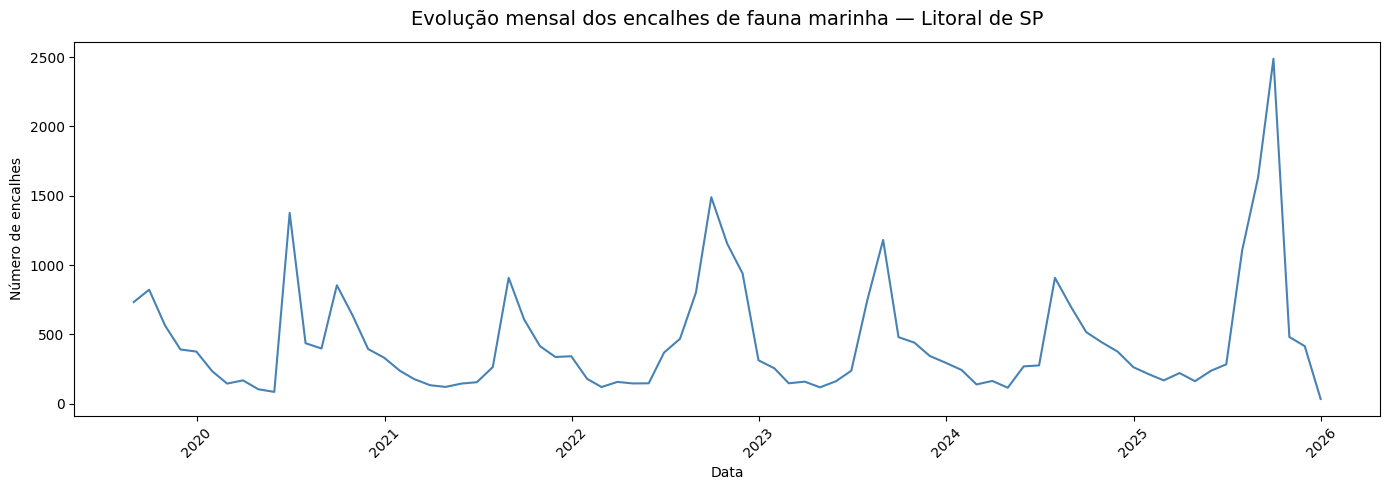


Meses com mais encalhes:
       Mês  Encalhes
2025-09-30      2489
2025-08-31      1632
2022-09-30      1490
2020-06-30      1377
2023-08-31      1182


In [ ]:
# Agrupa encalhes por mês e conta ocorrências
serie_mensal = df_temporal.resample('ME').size().reset_index()
serie_mensal.columns = ['Mês', 'Encalhes']

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=serie_mensal, x='Mês', y='Encalhes', ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Evolução mensal dos encalhes de fauna marinha — Litoral de SP', fontsize=14, pad=12)
ax.set_xlabel('Data')
ax.set_ylabel('Número de encalhes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nMeses com mais encalhes:')
print(serie_mensal.nlargest(5, 'Encalhes').to_string(index=False))


1.3 Sazonalidede - Média de ancalhes por mês do ano

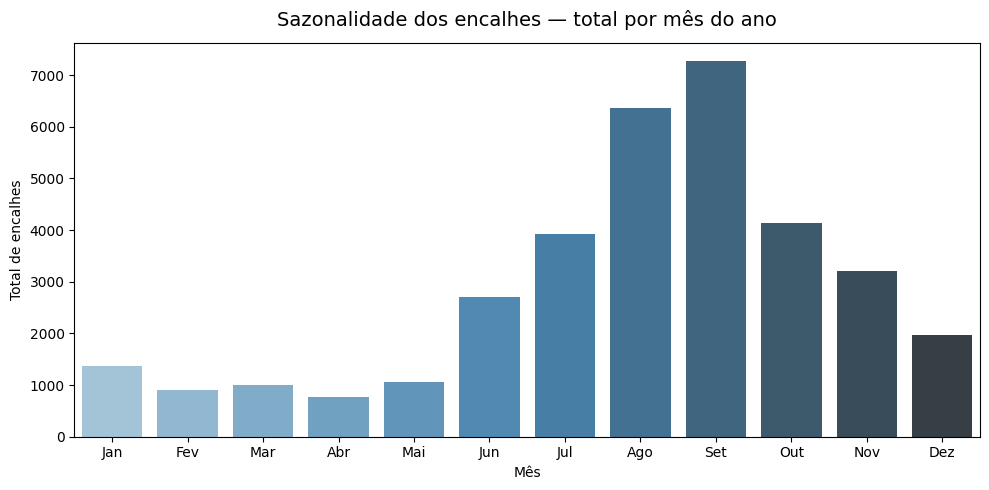

In [ ]:
# Agrupa por mês do ano (1 a 12) para identificar padrão sazonal
df_temporal['mes_do_ano'] = df_temporal.index.month
sazonalidade = df_temporal.groupby('mes_do_ano').size().reset_index()
sazonalidade.columns = ['Mês', 'Total de encalhes']
sazonalidade['Mês Nome'] = sazonalidade['Mês'].map({
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
})

ordem_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=sazonalidade, x='Mês Nome', y='Total de encalhes', ax=ax,
            hue='Mês Nome', palette='Blues_d', order=ordem_meses, legend=False)
ax.set_title('Sazonalidade dos encalhes — total por mês do ano', fontsize=14, pad=12)
ax.set_xlabel('Mês')
ax.set_ylabel('Total de encalhes')
plt.tight_layout()
plt.show()

1.4 Encalhes por classe de Animal

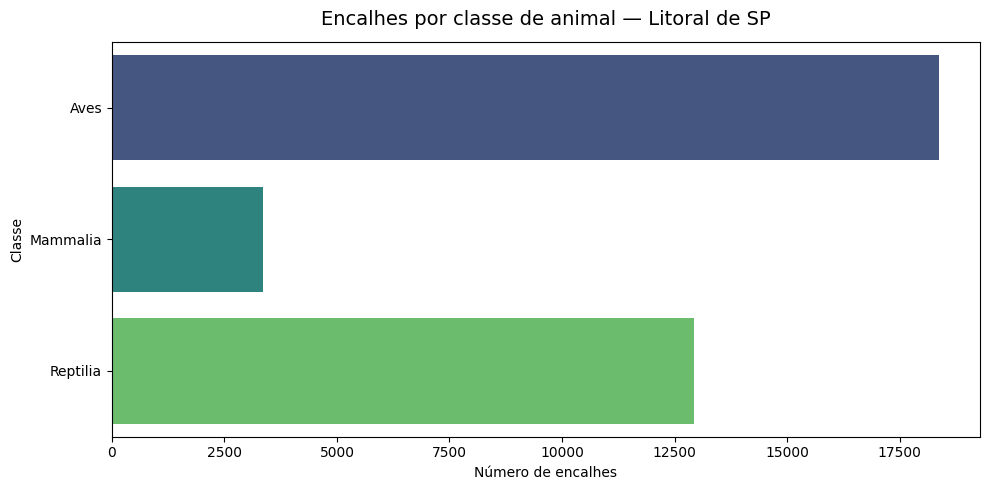

  Classe  Encalhes
    Aves     18368
Reptilia     12940
Mammalia      3350


In [ ]:
# Usa a coluna de Classe das Ocorrências (sufixo _ocor)
col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in df_master.columns else 'Espécies - Classe'

contagem_classe = df_master[col_classe].value_counts().reset_index()
contagem_classe.columns = ['Classe', 'Encalhes']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=contagem_classe, x='Encalhes', y='Classe', ax=ax,
            hue='Classe', palette='viridis', legend=False)
ax.set_title('Encalhes por classe de animal — Litoral de SP', fontsize=14, pad=12)
ax.set_xlabel('Número de encalhes')
ax.set_ylabel('Classe')
plt.tight_layout()
plt.show()

print(contagem_classe.to_string(index=False))



1.5 Proporção de animais vivos vs mortos

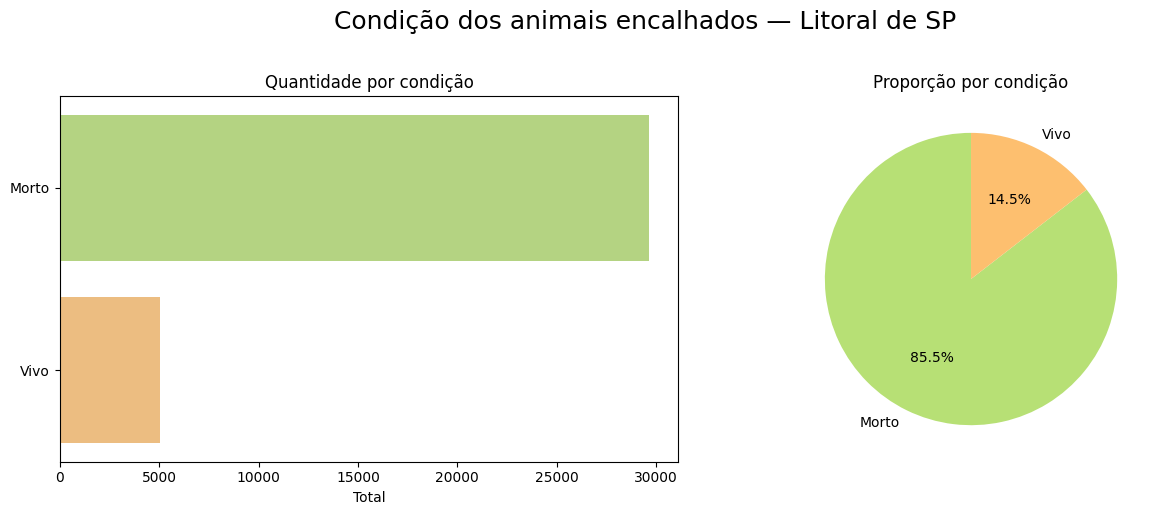

In [ ]:
contagem_condicao = df_master['Condição'].value_counts().reset_index()
contagem_condicao.columns = ['Condição', 'Total']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras
sns.barplot(data=contagem_condicao, x='Total', y='Condição', ax=axes[0],
            hue='Condição', palette='RdYlGn_r', legend=False)
axes[0].set_title('Quantidade por condição', fontsize=12)
axes[0].set_xlabel('Total')
axes[0].set_ylabel('')

# Gráfico de pizza
axes[1].pie(contagem_condicao['Total'], labels=contagem_condicao['Condição'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('RdYlGn_r', len(contagem_condicao)))
axes[1].set_title('Proporção por condição', fontsize=12)

plt.suptitle('Condição dos animais encalhados — Litoral de SP', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

1.6 Taxa de encalhes normalizada pelo esforço de monitoramento

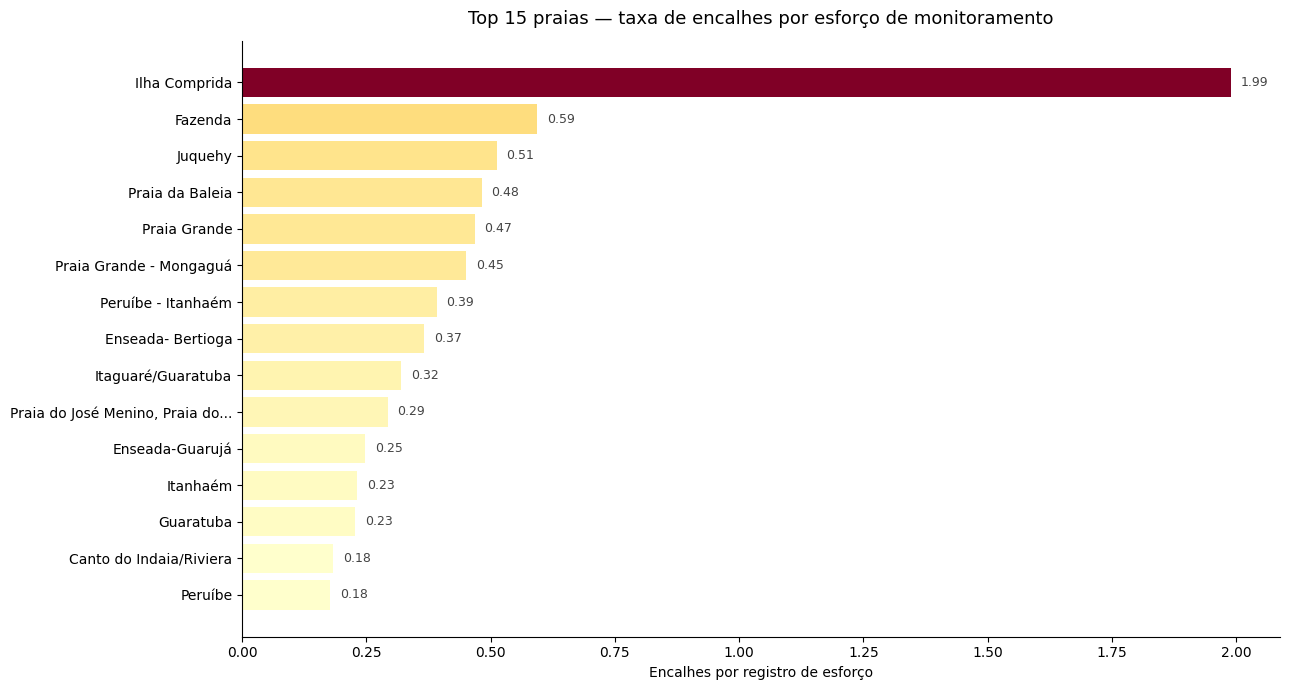

In [ ]:
# Conta encalhes e esforço por praia e calcula a taxa
encalhes_por_praia = df_master['Praia'].value_counts().reset_index()
encalhes_por_praia.columns = ['Praia', 'Encalhes']

esforco_por_praia = esforco_monitora_filtrada['Praia'].value_counts().reset_index()
esforco_por_praia.columns = ['Praia', 'Esforço']

taxa_normalizada = pd.merge(encalhes_por_praia, esforco_por_praia, on='Praia', how='inner')
taxa_normalizada['Taxa'] = taxa_normalizada['Encalhes'] / taxa_normalizada['Esforço']
taxa_normalizada = taxa_normalizada.sort_values('Taxa', ascending=False)

top15 = taxa_normalizada.head(15).copy()
top15['Praia'] = top15['Praia'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)

norm = plt.Normalize(top15['Taxa'].min(), top15['Taxa'].max())
cmap = plt.get_cmap('YlOrRd')
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(top15['Praia'], top15['Taxa'], color=[cmap(norm(v)) for v in top15['Taxa']])

for bar, val in zip(bars, top15['Taxa']):
    ax.text(bar.get_width() + top15['Taxa'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9, color='#444')

ax.set_title('Top 15 praias — taxa de encalhes por esforço de monitoramento', fontsize=13, pad=12)
ax.set_xlabel('Encalhes por registro de esforço')
ax.set_ylabel('')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

> **Resumo da preparação da Análise Exploratória e Séries Temporais:**  
> - **1.2** → Série temporal mensal: identifica tendências e picos ao longo dos anos  
> - **1.3** → Sazonalidade: revela quais meses concentram mais encalhes  
> - **1.4** → Encalhes por classe: mostra quais grupos taxonômicos são mais afetados  
> - **1.5** → Condição dos animais: proporção vivos vs mortos (objetivo específico do TCC)  
> - **1.6** → Taxa normalizada: compara praias com justiça, descontando o esforço de monitoramento  
>
> Os resultados desta fase respondem diretamente aos objetivos específicos do TCC e alimentam a Fase 4 (mapas espaciais).

---

## Geoprocessamento e Análise Espacial

1.1 Correção das coordenadas — Ocorrências

In [ ]:
def corrigir_coordenada(valor):
    s = str(valor).strip()
    if s in ('nan', 'None', ''):
        return np.nan

    # Remove todos os pontos e vírgulas
    sinal = '-' if s.startswith('-') else ''
    digitos = s.lstrip('-').replace('.', '').replace(',', '')

    # Sempre 2 dígitos na parte inteira para o litoral de SP
    resultado = sinal + digitos[:2] + '.' + digitos[2:]

    try:
        return float(resultado)
    except:
        return np.nan

ocorrencias_filtradas['Ponto - Lat'] = ocorrencias_filtradas['Ponto - Lat'].apply(corrigir_coordenada)
ocorrencias_filtradas['Ponto - Long'] = ocorrencias_filtradas['Ponto - Long'].apply(corrigir_coordenada)

print('Coordenadas corrigidas — primeiros valores:')
print(ocorrencias_filtradas[['Ponto - Lat', 'Ponto - Long']].head())


Coordenadas corrigidas — primeiros valores:
   Ponto - Lat  Ponto - Long
0   -24.985718    -47.851675
1   -23.794842    -45.365090
2   -23.803703    -45.364987
3   -24.849238    -47.691654
4   -23.516686    -45.165459


1.2 Correção das coordenadas — Esforços de Monitoramento

In [ ]:
# Aplicar a mesma função nas 4 colunas de coordenadas dos Esforços
colunas_coord = [
    'Latitude ponto inicial', 'Longitude ponto inicial',
    'Latitude ponto final',   'Longitude ponto final'
]

for col in colunas_coord:
    esforco_monitora_filtrada[col] = esforco_monitora_filtrada[col].apply(corrigir_coordenada)

print('Coordenadas dos Esforços corrigidas — primeiros valores:')
print(esforco_monitora_filtrada[colunas_coord].head())

Coordenadas dos Esforços corrigidas — primeiros valores:
   Latitude ponto inicial  Longitude ponto inicial  Latitude ponto final  \
0              -23.565005               -45.216021            -23.565630   
1              -24.573690               -47.245380            -24.621150   
2              -23.378924               -44.954236            -23.378931   
3              -23.392841               -44.972134            -23.378767   
4              -23.421360               -45.039336            -23.413394   

   Longitude ponto final  
0             -45.214758  
1             -47.328330  
2             -44.954361  
3             -44.954758  
4             -45.031554  


1.3 Criando GeoDataFrame de pontos — Encalhes

In [ ]:
# Cria uma cópia do df_master com as coordenadas já corrigidas
df_geo = df_master.copy()
df_geo['Ponto - Lat'] = ocorrencias_filtradas['Ponto - Lat']
df_geo['Ponto - Long'] = ocorrencias_filtradas['Ponto - Long']

# Remove linhas sem coordenadas válidas
df_geo = df_geo.dropna(subset=['Ponto - Lat', 'Ponto - Long'])

# Cria coluna geometry: cada encalhe vira um ponto (longitude, latitude)
df_geo['geometry'] = df_geo.apply(
    lambda row: Point(row['Ponto - Long'], row['Ponto - Lat']), axis=1
)

# Transforma em GeoDataFrame com CRS WGS84 (padrão GPS / SIMBA)
gdf_encalhes = gpd.GeoDataFrame(df_geo, geometry='geometry', crs='EPSG:4326')

print(f' GeoDataFrame de encalhes criado:')
print(f'   Registros com coordenadas válidas: {len(gdf_encalhes)}')
print(f'   CRS: {gdf_encalhes.crs}')
print(gdf_encalhes[['Ponto - Lat', 'Ponto - Long', 'geometry']].head())

 GeoDataFrame de encalhes criado:
   Registros com coordenadas válidas: 34144
   CRS: EPSG:4326
   Ponto - Lat  Ponto - Long                     geometry
0   -24.985718    -47.851675  POINT (-47.85168 -24.98572)
1   -23.794842    -45.365090  POINT (-45.36509 -23.79484)
2   -23.803703    -45.364987   POINT (-45.36499 -23.8037)
3   -24.849238    -47.691654  POINT (-47.69165 -24.84924)
4   -23.516686    -45.165459  POINT (-45.16546 -23.51669)


1.4 Criando GeoDataFrame de linhas — Esforços de Monitoramento

In [ ]:
# Cria uma linha geográfica para cada saída de monitoramento
esforco_geo = esforco_monitora_filtrada.dropna(subset=colunas_coord).copy()

esforco_geo['geometry'] = esforco_geo.apply(
    lambda row: LineString([
        (row['Longitude ponto inicial'], row['Latitude ponto inicial']),
        (row['Longitude ponto final'], row['Latitude ponto final'])
    ]), axis=1
)

gdf_esforcos = gpd.GeoDataFrame(esforco_geo, geometry='geometry', crs='EPSG:4326')

print(f'Total de rotas de monitoramento com coordenadas válidas: {len(gdf_esforcos)}')

Total de rotas de monitoramento com coordenadas válidas: 428371


1.5 Mapa estático dos encalhes — GeoPandas

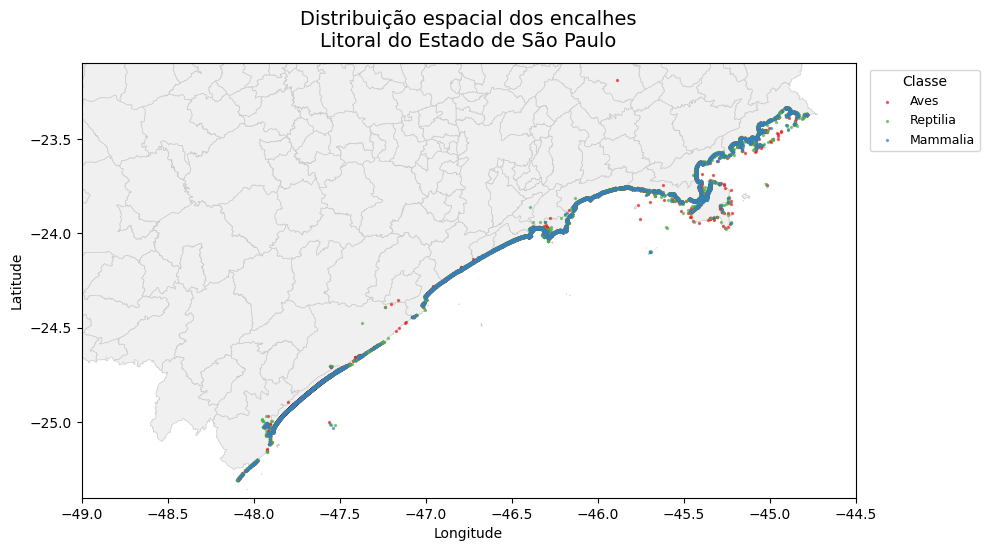

In [ ]:
url_sp = 'https://github.com/alura-cursos/curso_geopandas/raw/main/dados/Estado_SP.shp'
sp = gpd.read_file(url_sp)

# Garante que o CRS é o mesmo dos encalhes (EPSG:4326)
sp = sp.to_crs(epsg=4326)

# Filtra apenas o litoral de SP (bounding box)
gdf_plot_geo = gdf_encalhes[
    gdf_encalhes['Ponto - Lat'].between(-26, -22) &
    gdf_encalhes['Ponto - Long'].between(-49, -44)
].copy()

# Define coluna de classe e cores por classe
col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_plot_geo.columns else 'Espécies - Classe'
cores_por_classe = {
    'Aves':           '#e41a1c',  # vermelho
    'Reptilia':       '#4daf4a',  # verde
    'Mammalia':       '#377eb8',  # azul
    'Elasmobranchii': '#ff7f00',  # laranja
    'Sirenia':        '#984ea3',  # roxo
}
cor_padrao = '#aaaaaa'

fig, ax = plt.subplots(figsize=(10, 13))

# Plota o mapa base do estado de SP
sp.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

# Plota os pontos de encalhe por classe de animal
classes = gdf_plot_geo[col_classe].dropna().unique()
for classe in classes:
    subset = gdf_plot_geo[gdf_plot_geo[col_classe] == classe]
    cor = cores_por_classe.get(str(classe), cor_padrao)
    subset.plot(ax=ax, markersize=2, alpha=0.6, color=cor, label=str(classe))

# Ajusta o zoom para o litoral
ax.set_xlim(-49, -44.5)
ax.set_ylim(-25.4, -23.1)

ax.set_title('Distribuição espacial dos encalhes\nLitoral do Estado de São Paulo', fontsize=14, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Classe', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 1.5b Distribuição espacial por município — Top 15


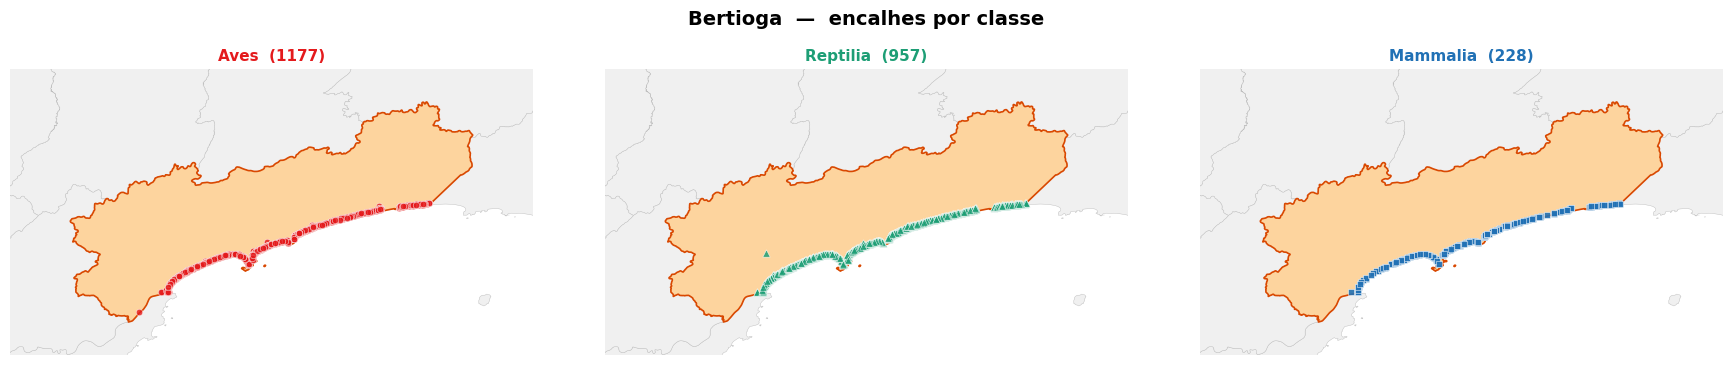

In [ ]:
# ── Bertioga — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Bertioga'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Bertioga  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Bertioga')

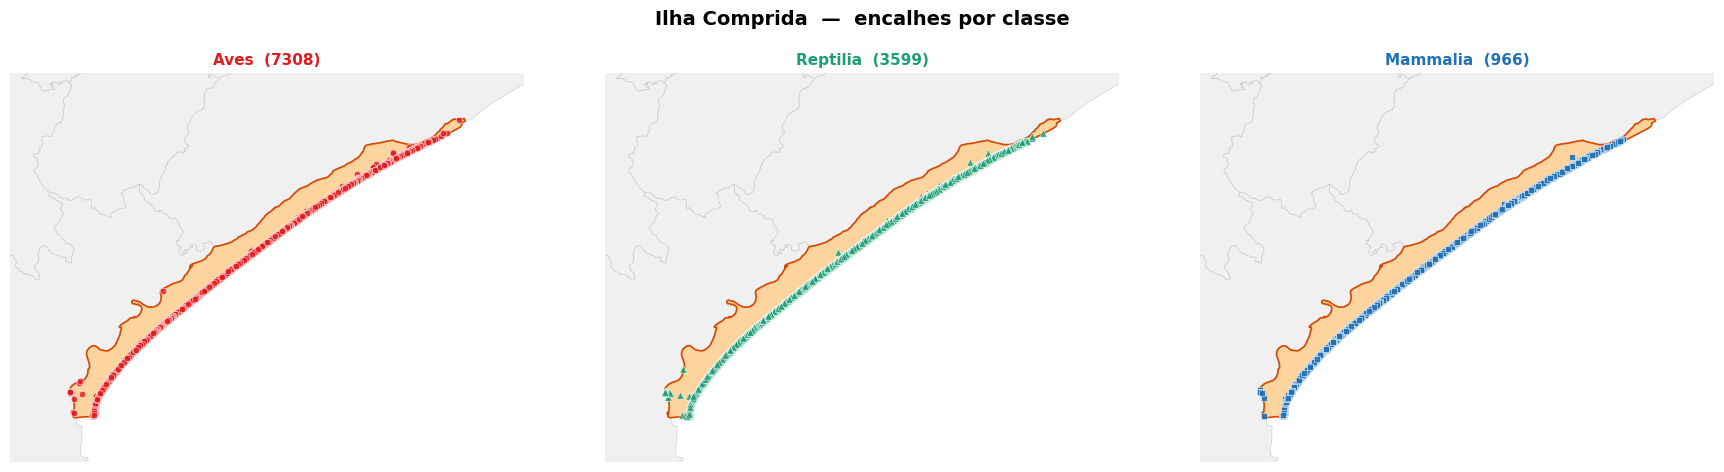

In [ ]:
# ── Ilha Comprida — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Ilha Comprida'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Ilha Comprida  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Ilha Comprida')

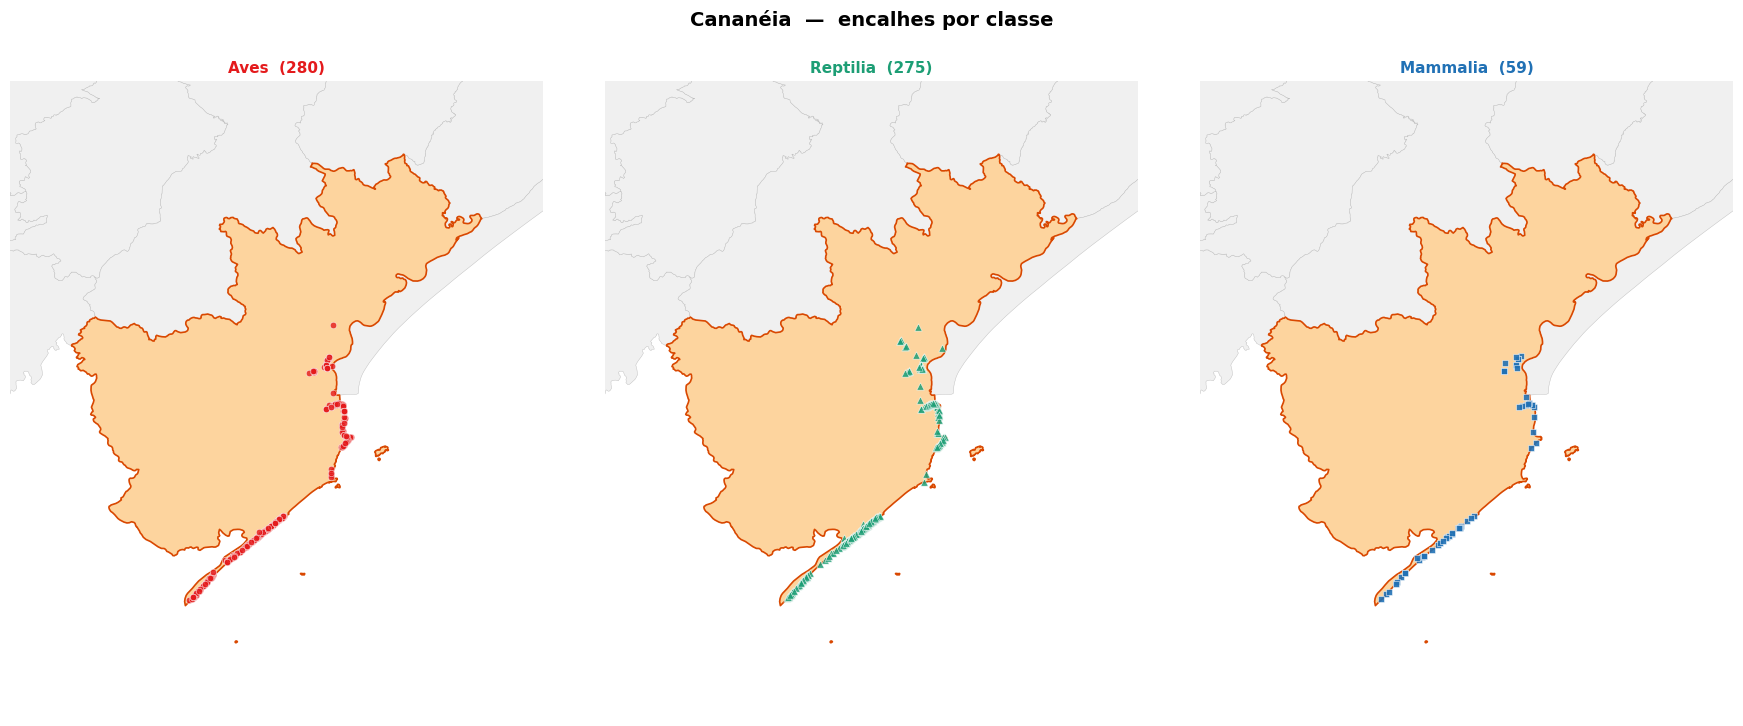

In [ ]:
# ── Cananéia — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Cananéia'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Cananéia  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Cananéia')

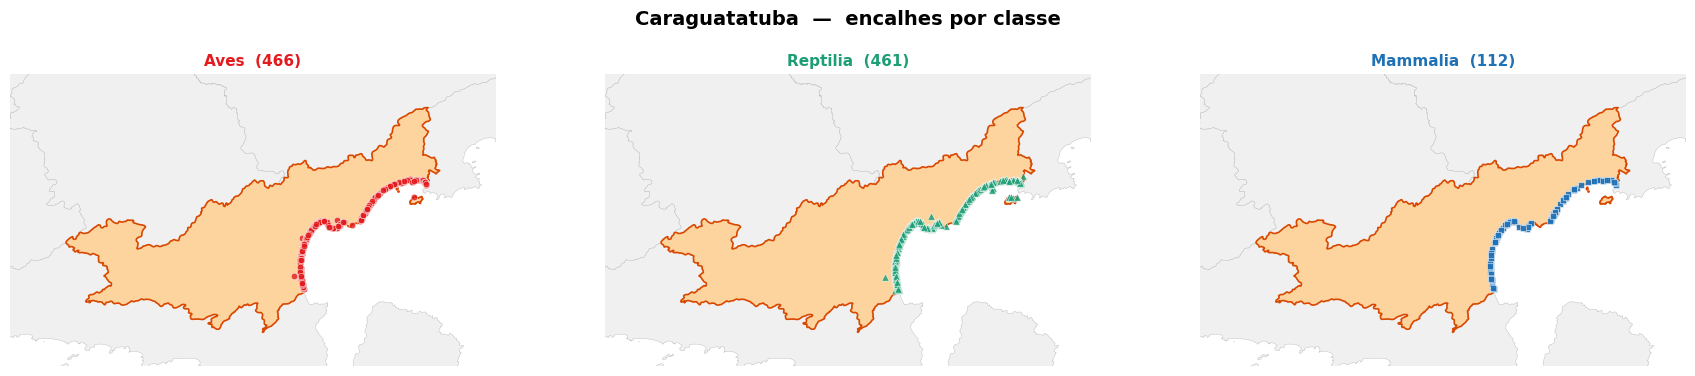

In [ ]:
# ── Caraguatatuba — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Caraguatatuba'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Caraguatatuba  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Caraguatatuba')

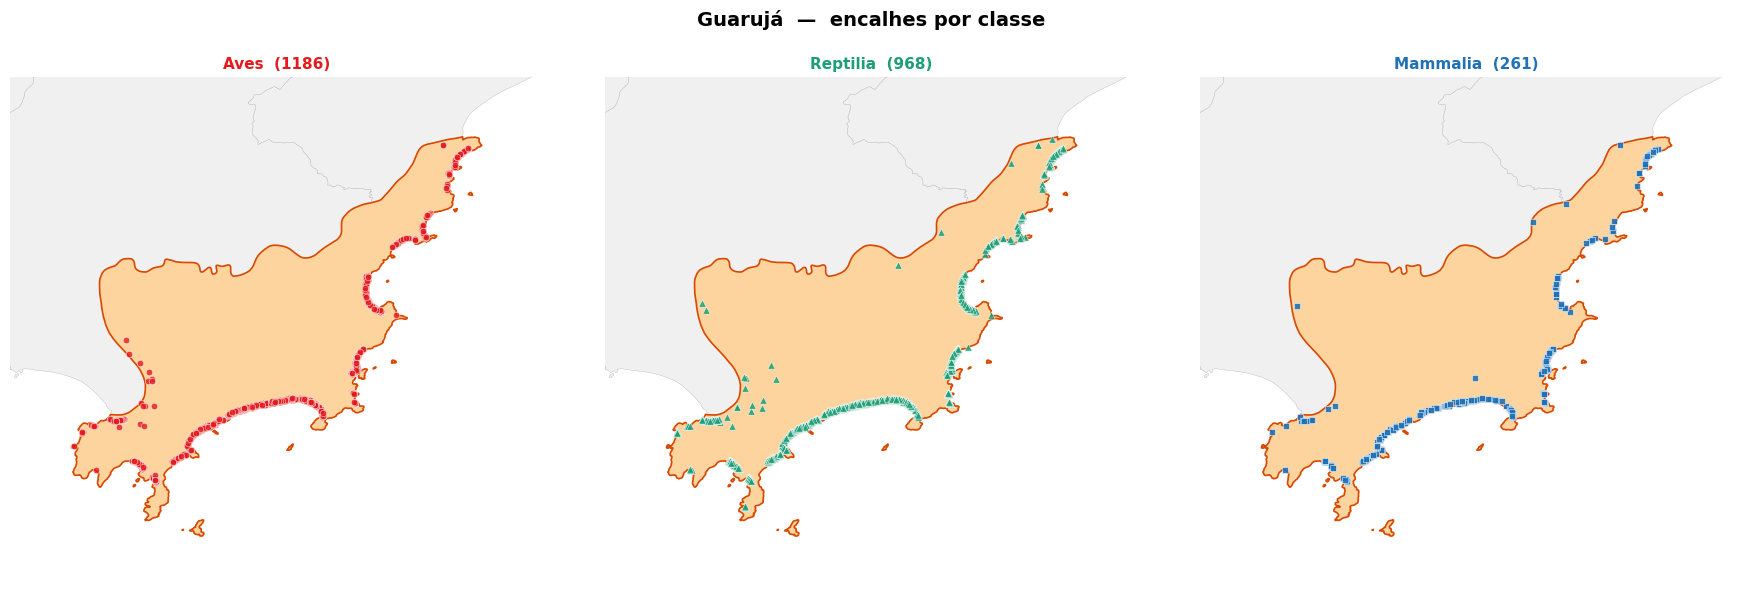

In [ ]:
# ── Guarujá — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Guarujá'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Guarujá  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Guarujá')

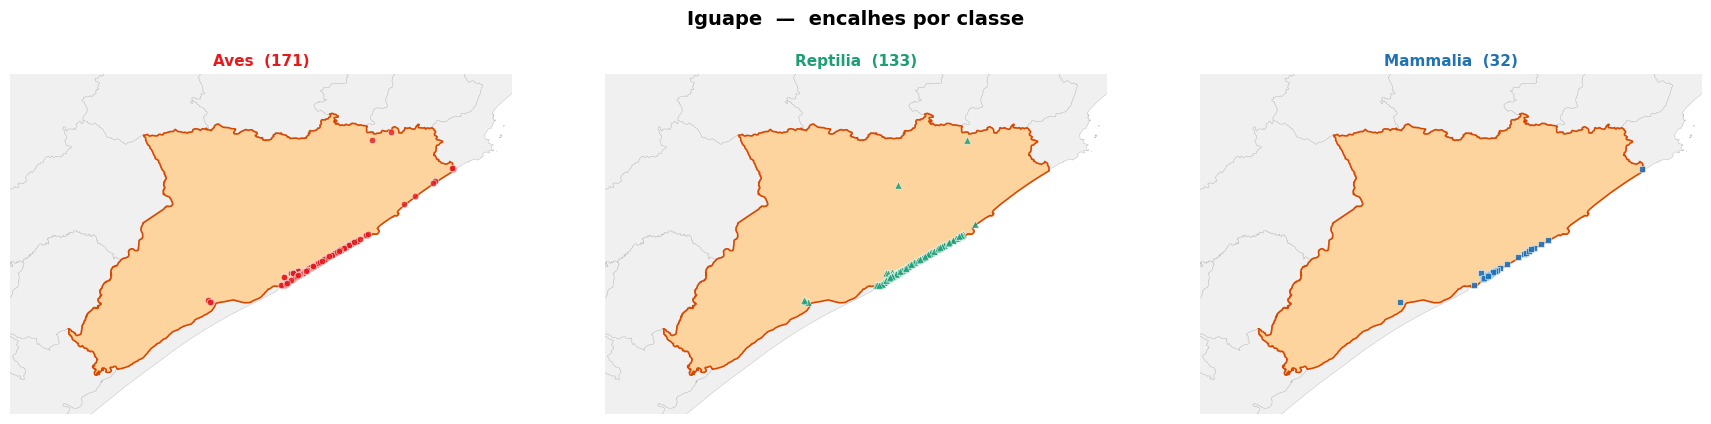

In [ ]:
# ── Iguape — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Iguape'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Iguape  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Iguape')

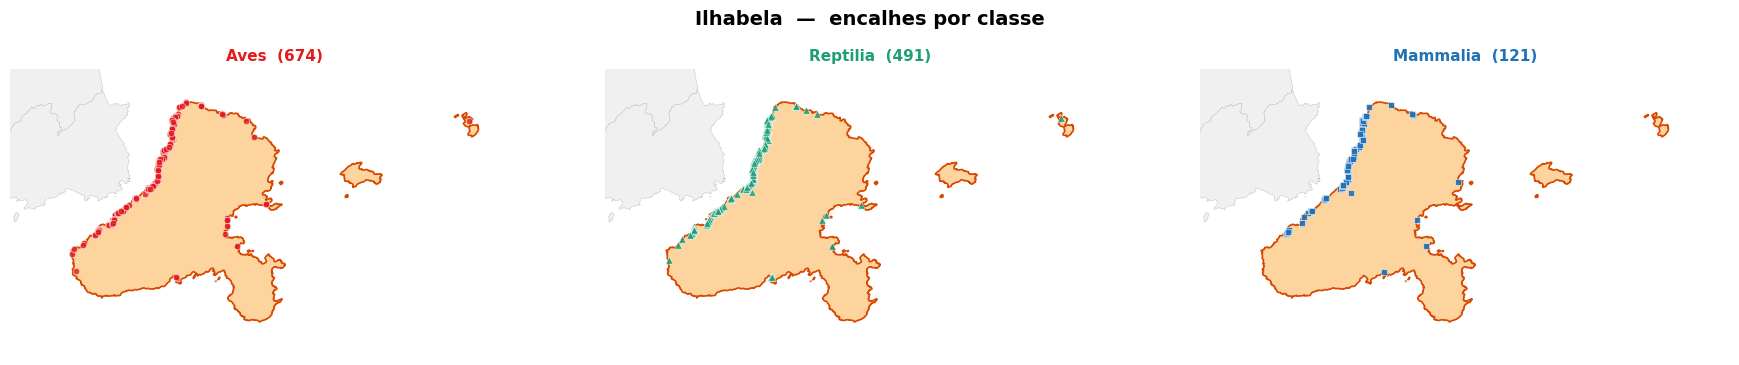

In [ ]:
# ── Ilhabela — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Ilhabela'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Ilhabela  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Ilhabela')

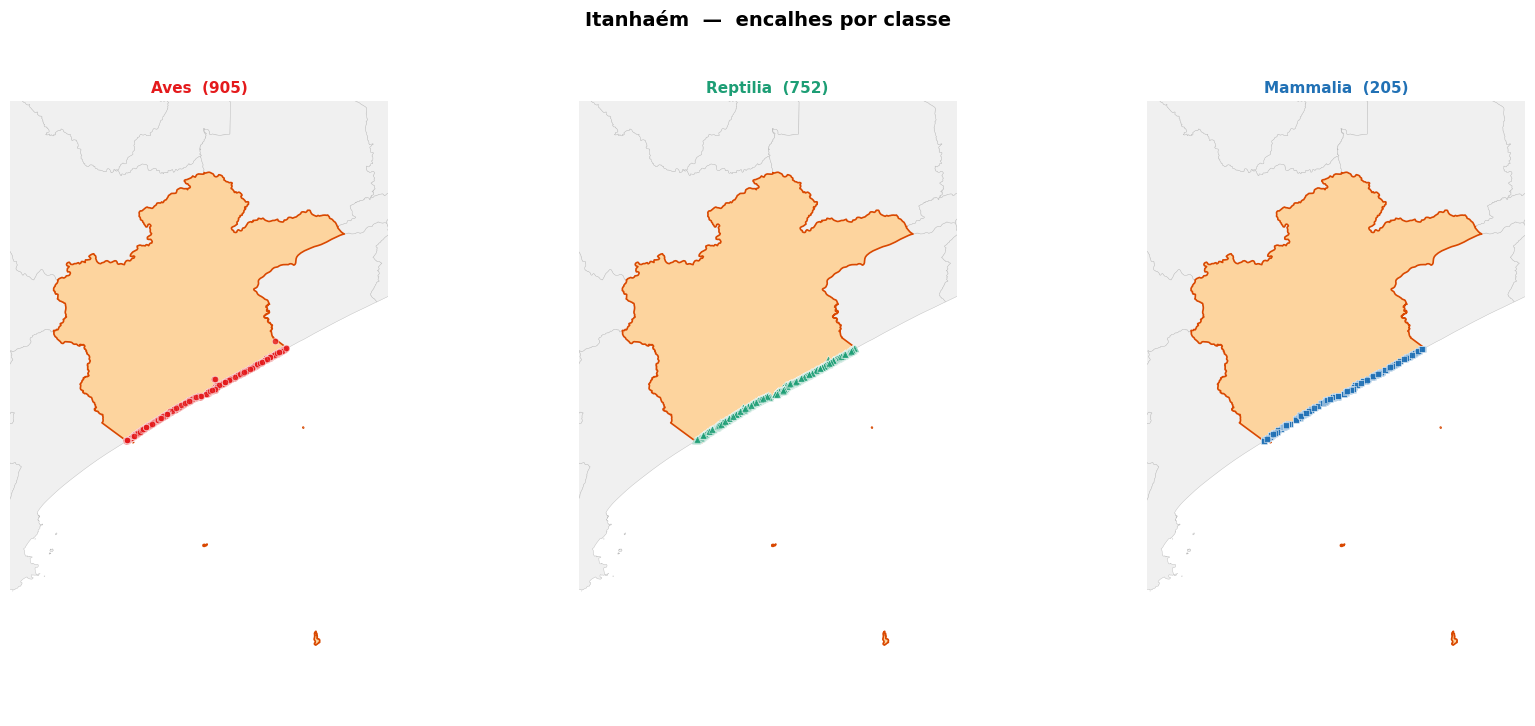

In [ ]:
# ── Itanhaém — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Itanhaém'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Itanhaém  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Itanhaém')

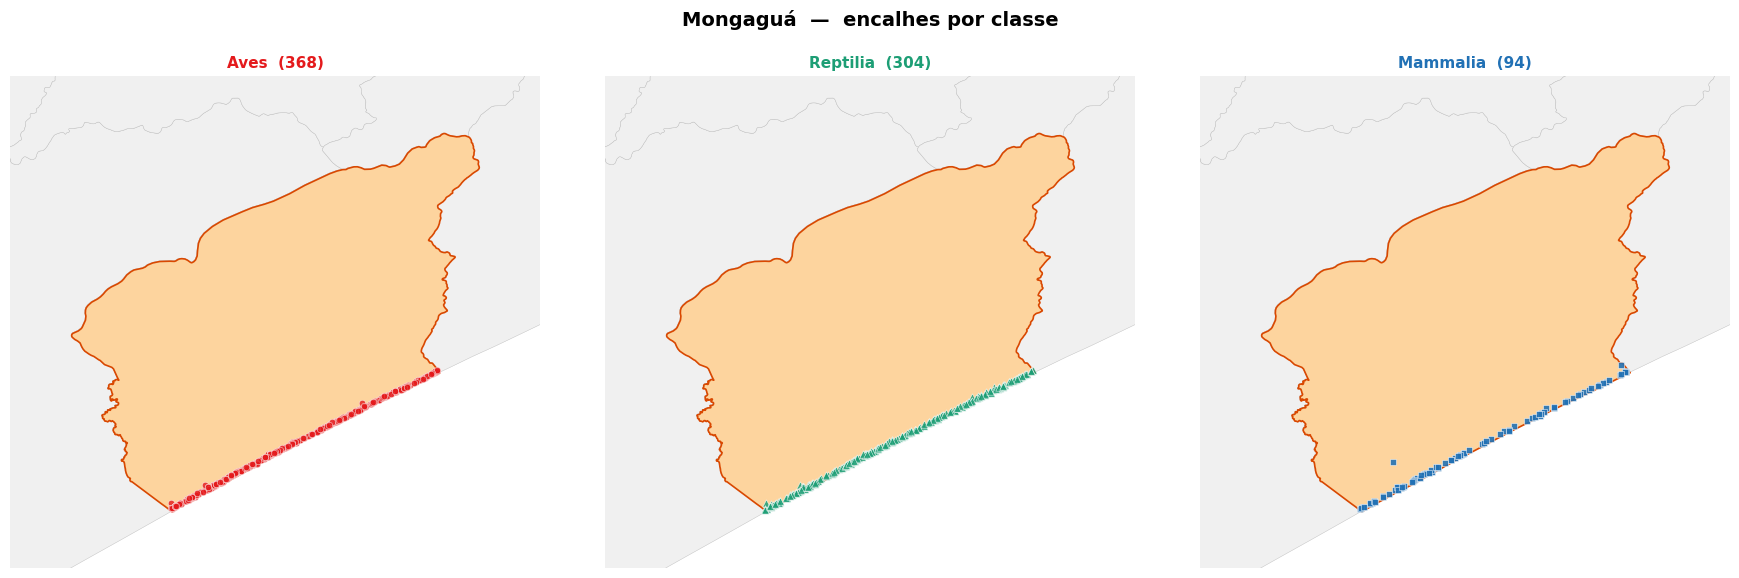

In [ ]:
# ── Mongaguá — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Mongaguá'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Mongaguá  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Mongaguá')

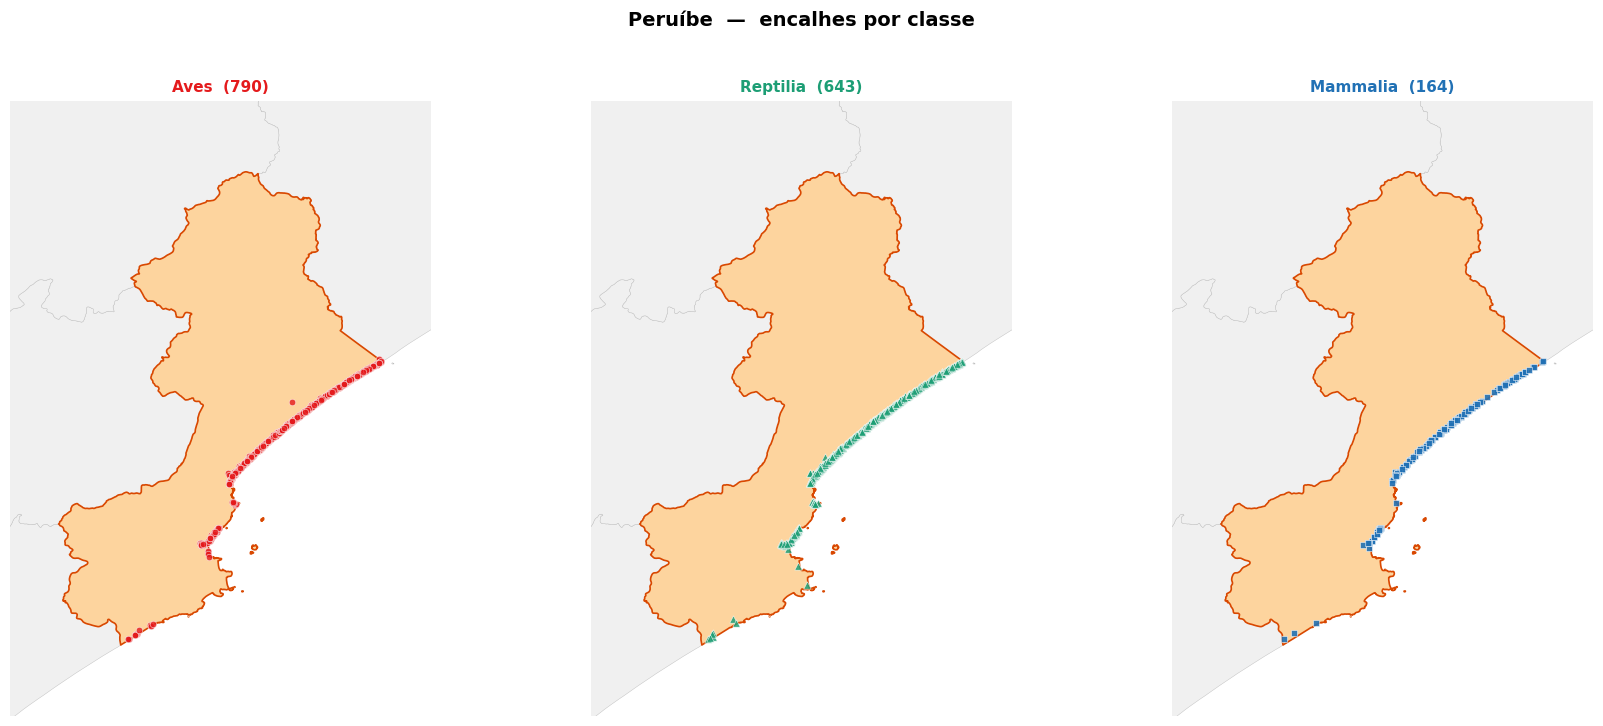

In [ ]:
# ── Peruíbe — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Peruíbe'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Peruíbe  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Peruíbe')

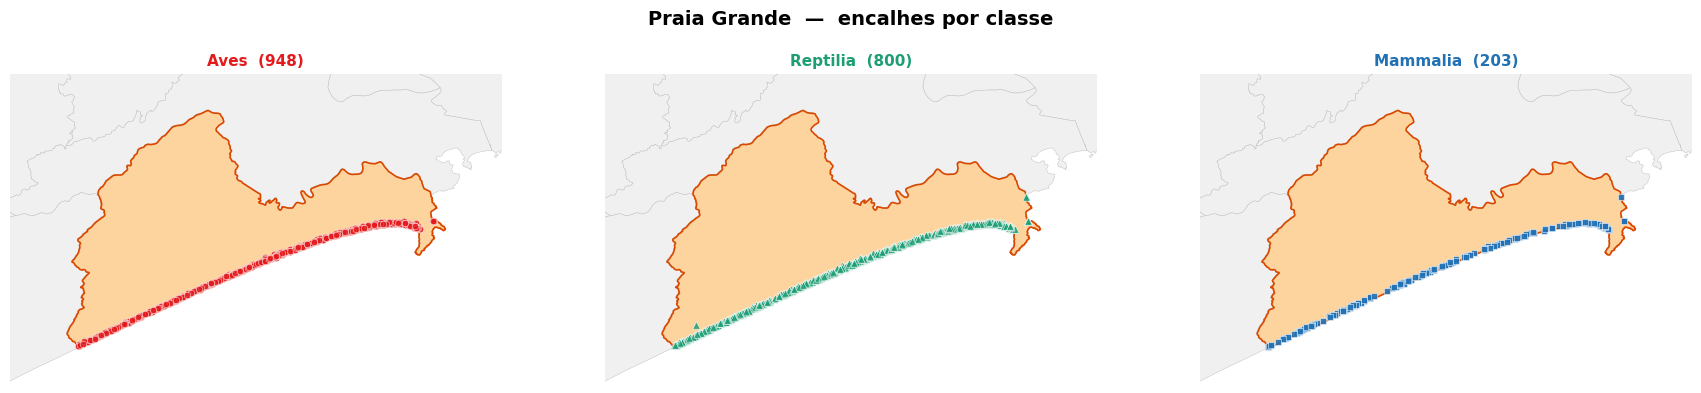

In [ ]:
# ── Praia Grande — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Praia Grande'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Praia Grande  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Praia Grande')

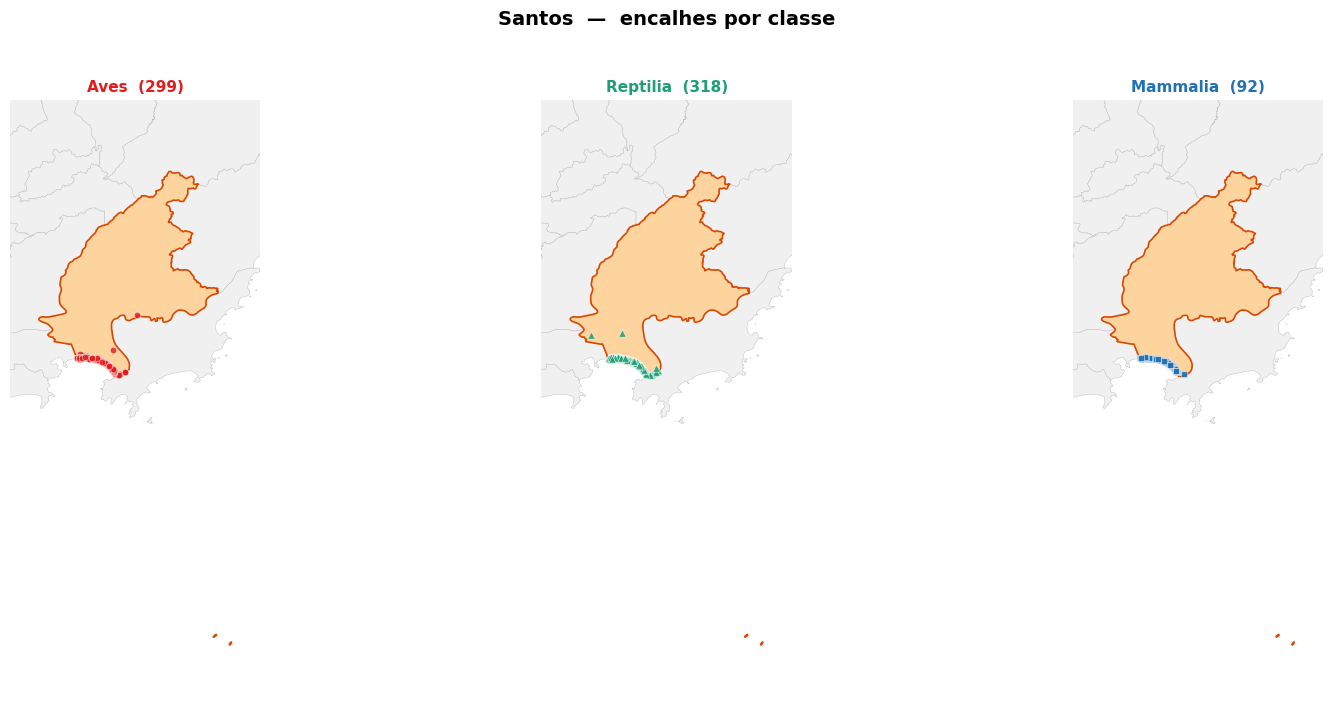

In [ ]:
# ── Santos — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Santos'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Santos  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Santos')

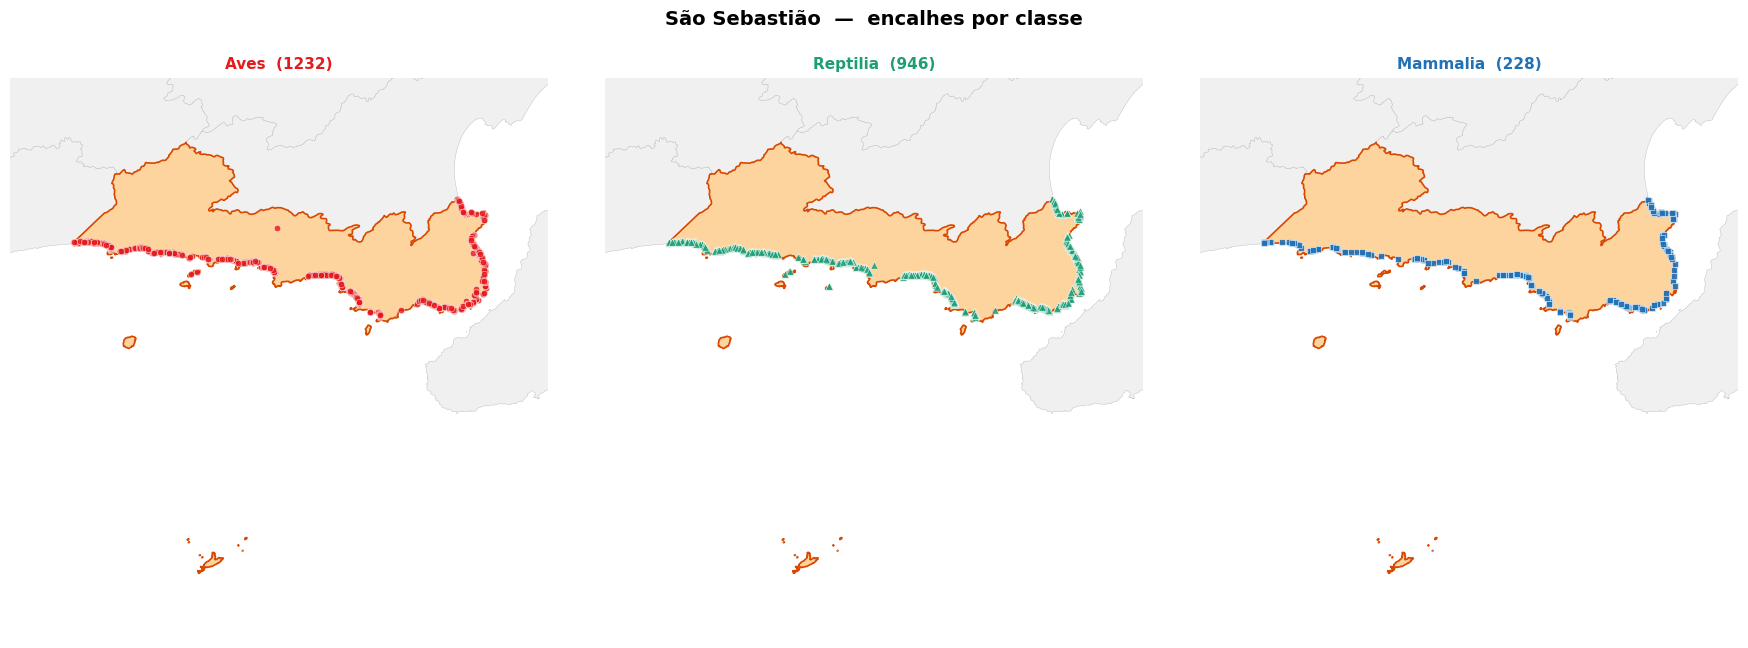

In [ ]:
# ── São Sebastião — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'São Sebastião'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('São Sebastião  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: São Sebastião')

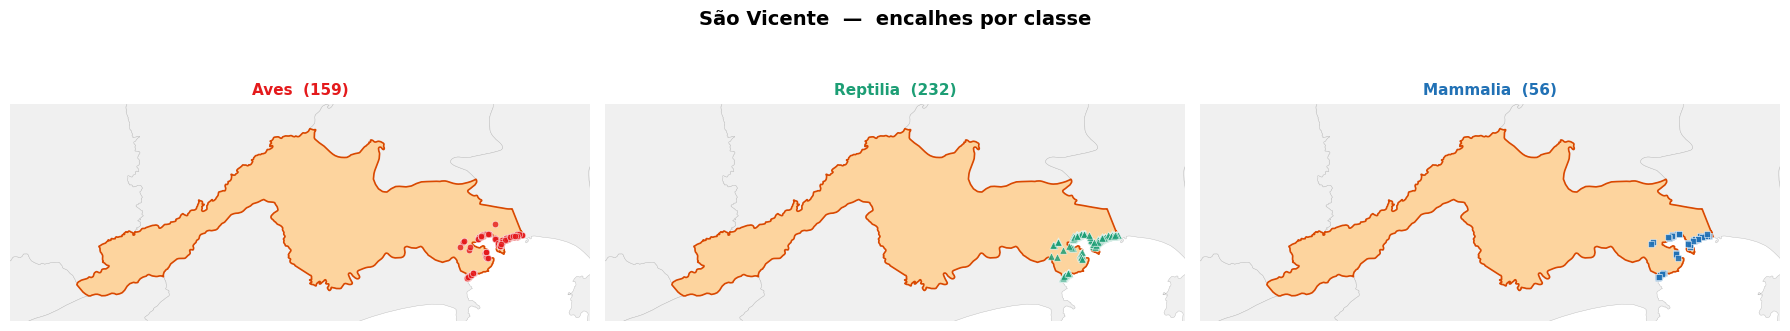

In [ ]:
# ── São Vicente — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'São Vicente'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('São Vicente  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: São Vicente')

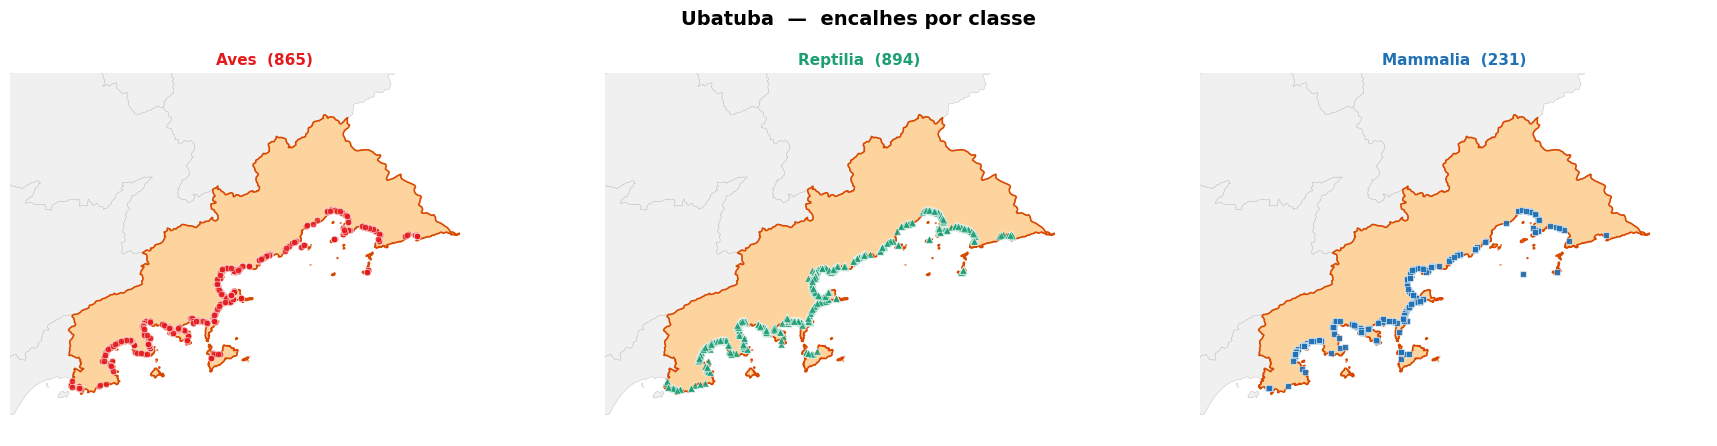

In [ ]:
# ── Ubatuba — facet por classe ──────────────────────────────────────────

col_classe = 'Espécies - Classe_ocor' if 'Espécies - Classe_ocor' in gdf_encalhes.columns else 'Espécies - Classe'

classes_cfg = {
    'Aves':     {'cor': '#e41a1c', 'marker': 'o', 'size': 22, 'alpha': 0.80},
    'Reptilia': {'cor': '#1D9E75', 'marker': '^', 'size': 28, 'alpha': 0.85},
    'Mammalia': {'cor': '#2171b5', 'marker': 's', 'size': 24, 'alpha': 0.90},
}

mun_geo = sp[sp['NM_MUN'] == 'Ubatuba'].copy()

if not mun_geo.empty:
    encalhes_filtrados = gdf_encalhes[
        gdf_encalhes['Ponto - Lat'].between(-26, -22) &
        gdf_encalhes['Ponto - Long'].between(-49, -44) &
        gdf_encalhes[col_classe].isin(['Aves', 'Reptilia', 'Mammalia'])
    ].copy()

    encalhes_dentro = gpd.sjoin(
        encalhes_filtrados,
        mun_geo[['NM_MUN', 'geometry']],
        how='inner', predicate='within'
    )

    bounds = mun_geo.total_bounds  # [xmin, ymin, xmax, ymax]
    w = bounds[2] - bounds[0]
    h = bounds[3] - bounds[1]

    # Margem fixa de 15% em cada lado
    mx = w * 0.15
    my = h * 0.15
    xmin, xmax = bounds[0] - mx, bounds[2] + mx
    ymin, ymax = bounds[1] - my, bounds[3] + my

    # Proporção real do município (graus lon × lat)
    # figsize: largura fixa 18, altura proporcional ao aspecto do bbox
    aspect = (ymax - ymin) / (xmax - xmin)
    fig_h = max(3.5, min(7.0, 18 * aspect / 3))  # por painel; clamp 3.5–7
    fig, axes = plt.subplots(1, 3, figsize=(18, fig_h))
    fig.suptitle('Ubatuba  —  encalhes por classe', fontsize=14, fontweight='bold', y=1.03)

    for ax, (classe, cfg) in zip(axes, classes_cfg.items()):
        sp.plot(ax=ax, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.3)
        mun_geo.plot(ax=ax, color='#fdd49e', edgecolor='#d94801', linewidth=1.2, zorder=2)

        subset = encalhes_dentro[encalhes_dentro[col_classe] == classe]

        if not subset.empty:
            ax.scatter(
                subset.geometry.x, subset.geometry.y,
                color=cfg['cor'], marker=cfg['marker'],
                s=cfg['size'], alpha=cfg['alpha'],
                edgecolors='white', linewidths=0.4, zorder=3,
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')   # mantém a forma geográfica correta
        ax.set_axis_off()
        n = len(subset) if not subset.empty else 0
        ax.set_title(f'{classe}  ({n})', fontsize=11, fontweight='bold',
                     color=cfg['cor'], pad=6)

    plt.tight_layout()
    plt.show()
else:
    print('Município não encontrado: Ubatuba')

1.6 Mapa de calor — Geopandas

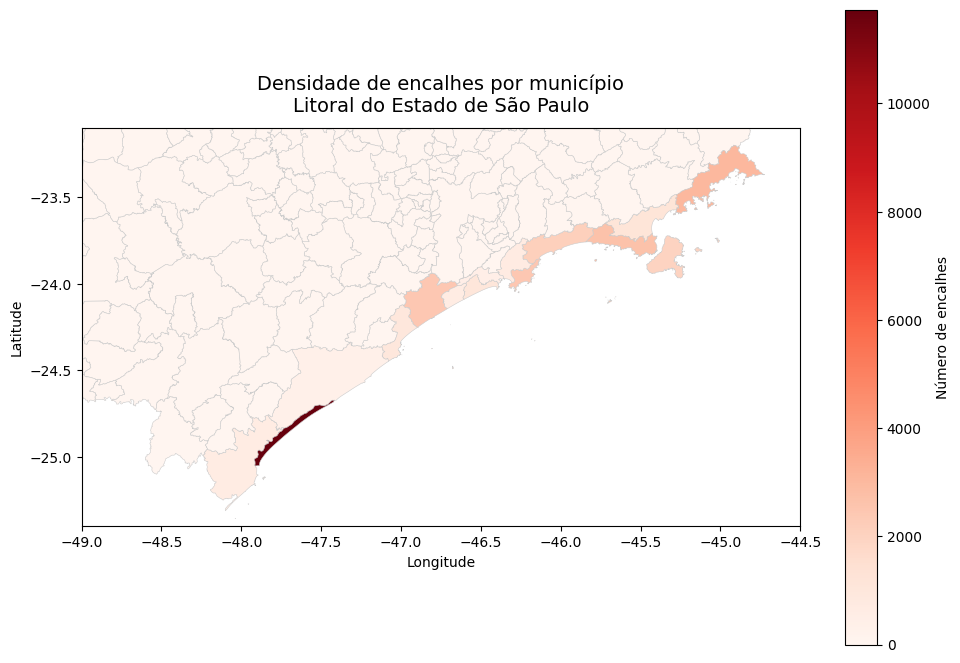

In [ ]:
# Agrupa encalhes por município e junta com o shapefile
encalhes_mun = gdf_encalhes['Cidade'].str.strip().str.upper().value_counts().reset_index()
encalhes_mun.columns = ['Cidade', 'Encalhes']

# Padroniza o nome do município no shapefile para fazer o merge
sp['NM_MUN_upper'] = sp['NM_MUN'].str.upper().str.strip()

# Une o shapefile com a contagem de encalhes
sp_encalhes = sp.merge(encalhes_mun, left_on='NM_MUN_upper', right_on='Cidade', how='left')
sp_encalhes['Encalhes'] = sp_encalhes['Encalhes'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 13))

# Plota os municípios coloridos pela quantidade de encalhes
sp_encalhes.plot(
    ax=ax,
    column='Encalhes',
    cmap='Reds',
    edgecolor='#cccccc',
    linewidth=0.4,
    legend=True,
    legend_kwds={'label': 'Número de encalhes', 'shrink': 0.5}
)

# Ajusta o zoom para o litoral
ax.set_xlim(-49, -44.5)
ax.set_ylim(-25.4, -23.1)


ax.set_title('Densidade de encalhes por município\nLitoral do Estado de São Paulo', fontsize=14, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


1.7 Encalhes por município

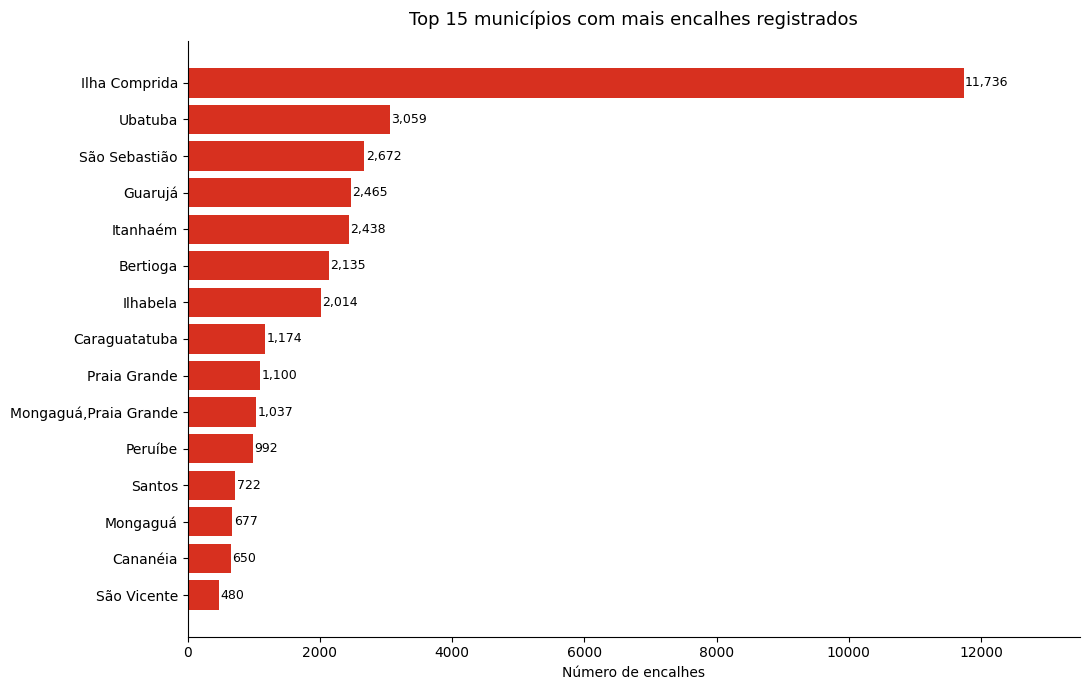

            Município  Encalhes
        Ilha Comprida     11736
              Ubatuba      3059
        São Sebastião      2672
              Guarujá      2465
             Itanhaém      2438
             Bertioga      2135
             Ilhabela      2014
        Caraguatatuba      1174
         Praia Grande      1100
Mongaguá,Praia Grande      1037
              Peruíbe       992
               Santos       722
             Mongaguá       677
             Cananéia       650
          São Vicente       480


In [ ]:
# Conta encalhes por município e plota os 15 com mais registros
encalhes_municipio = (
    gdf_encalhes['Cidade']
    .str.strip()                    # remove espaços extras
    .value_counts()
    .head(15)
    .reset_index()
)
encalhes_municipio.columns = ['Município', 'Encalhes']

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    encalhes_municipio['Município'][::-1],  # inverte para maior ficar no topo
    encalhes_municipio['Encalhes'][::-1],
    color='#d7301f'
)

# Rótulo com valor no final de cada barra
for bar, valor in zip(bars, encalhes_municipio['Encalhes'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{valor:,}', va='center', fontsize=9)

ax.set_title('Top 15 municípios com mais encalhes registrados', fontsize=13, pad=12)
ax.set_xlabel('Número de encalhes')
ax.set_ylabel('')
ax.set_xlim(0, encalhes_municipio['Encalhes'].max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Mostra tabela também para confirmar os números
print(encalhes_municipio.to_string(index=False))

> **Resumo do Geoprocessamento e Análise Espacial:**  
> - **1.1 / 1.2** → Coordenadas corrigidas para `float` nos dois datasets  
> - **1.3** → `gdf_encalhes`: GeoDataFrame de pontos (cada encalhe = um ponto no mapa)  
> - **1.4** → `gdf_esforcos`: GeoDataFrame de linhas (cada saída de monitoramento = uma linha)  
> - **1.5** → Mapa estático com GeoPandas: distribuição por classe de animal  
> - **1.6** → Mapa de calor com Geopandas: hotspots de encalhes no litoral paulista  
> - **1.7** → Encalhes por município: ranking dos municípios mais afetados  
